### KV Cache Compression: Low-Rank + Residual INT4 Quantization
This notebook implements a KV cache compression pipeline:
1. Capture K/V tensors during autoregressive prefill.
2. Decompose with truncated SVD.
3. Quantize the residual to INT4.
4. Integrate the compressed cache into token generation.
5. Run ablation studies on rank.

In [1]:
# ## 1. Imports and Model Loading
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
import numpy as np
import time
import gc

torch.manual_seed(42)

In [2]:
# Choose a small model for fast experimentation
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,   # keep float32 for SVD / quantization simplicity
    device_map="auto",
)
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [3]:
# ## 2. Helper Functions: SVD, Quantization, Reconstruction

def truncated_svd(x: torch.Tensor, r: int):
    """
    x: (seq_len, d) – key or value matrix for one head.
    Returns:
        L = U_r @ diag(S_r)   shape (seq_len, r)
        R = V_r.T             shape (r, d)
        x_lr = L @ R          shape (seq_len, d)  (the low-rank approximation)
    """
    U, S, Vh = torch.linalg.svd(x, full_matrices=False)  # U:(seq,d), S:(d,), Vh:(d,d)
    U_r = U[:, :r]                  # (seq, r)
    S_r = S[:r]                     # (r,)
    Vh_r = Vh[:r, :]                # (r, d)
    L = U_r * S_r.unsqueeze(0)      # (seq, r)
    x_lr = L @ Vh_r                 # (seq, d)
    return L, Vh_r, x_lr

def quantize_int4(residual: torch.Tensor):
    """
    residual: (seq_len, d) – floating point residual.
    Returns:
        scale: scalar
        q_res: (seq_len, d) – int8 tensor with values in [-7, 7]
    """
    b = 4
    qmax = 2**(b-1) - 1  # 7
    max_abs = residual.abs().max()
    scale = max_abs / qmax
    if scale == 0:
        scale = torch.tensor(1.0)
    q = torch.clamp(torch.round(residual / scale), -qmax, qmax).to(torch.int8)
    return scale, q

def dequantize_int4(q: torch.Tensor, scale: float) -> torch.Tensor:
    """q: int8, scale: float -> float tensor of same shape"""
    return q.float() * scale

def compress_head_kv(K_head: torch.Tensor, V_head: torch.Tensor, r: int):
    """
    K_head, V_head: (seq_len, d)
    Returns a dict with compressed components.
    """
    L_k, R_k, K_lr = truncated_svd(K_head, r)
    L_v, R_v, V_lr = truncated_svd(V_head, r)
    
    Rk = K_head - K_lr
    Rv = V_head - V_lr
    
    scale_k, Qk = quantize_int4(Rk)
    scale_v, Qv = quantize_int4(Rv)
    
    return {
        'L_k': L_k,            # (seq, r)
        'R_k': R_k,            # (r, d)
        'L_v': L_v,            # (seq, r)
        'R_v': R_v,            # (r, d)
        'scale_k': scale_k,
        'Qk': Qk,              # int8 (seq, d)
        'scale_v': scale_v,
        'Qv': Qv,              # int8 (seq, d)
    }

def reconstruct_head_kv(comp: dict) -> (torch.Tensor, torch.Tensor):
    """Return K_hat, V_hat of shape (seq_len, d)"""
    K_hat = comp['L_k'] @ comp['R_k'] + dequantize_int4(comp['Qk'], comp['scale_k'])
    V_hat = comp['L_v'] @ comp['R_v'] + dequantize_int4(comp['Qv'], comp['scale_v'])
    return K_hat, V_hat

In [4]:
# ## 3. KV Cache Extraction (safe, no unpacking)
def get_kv_cache_for_prompt(prompt: str):
    """Return the raw DynamicCache and the last token's logits."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, use_cache=True)
    return outputs.past_key_values, outputs.logits[:, -1, :]

prompt = '''
Bicameralism is a type of legislature that is divided into two separate assemblies, chambers, or houses, known as a bicameral legislature. Bicameralism is distinguished from unicameralism, in which all members deliberate and vote as a single group. As of 2022, roughly 40% of the world's national legislatures are bicameral, while unicameralism represents 60% nationally and much more at the subnational level.[1]Often, the members of the two chambers are elected or selected by different methods, which vary from jurisdiction to jurisdiction. This can often lead to the two chambers having very different compositions of members.Enactment of primary legislation often requires a concurrent majority—the approval of a majority of members in each of the chambers of the legislature. When this is the case, the legislature may be called an example of perfect bicameralism. However, in many parliamentary and semi-presidential systems, the house to which the executive is responsible (e.g. House of Commons of the UK and National Assembly of France) can overrule the other house (e.g. House of Lords of the UK and Senate of France) and may be regarded as an example of imperfect bicameralism. Some legislatures lie in between these two positions, with one house able to overrule the other only under certain circumstances. Significance of the British Parliament Main article: Parliament of the United Kingdom The British Parliament is often referred to as the \"Mother of Parliaments\" (in fact a misquotation of John Bright, who remarked in 1865 that \"England is the Mother of Parliaments\") because the British Parliament has been the model for most other parliamentary systems, and its Acts have created many other parliaments.[2] The origins of British bicameralism can be traced to 1341, when the Commons met separately from the nobility and clergy for the first time, creating what was effectively an Upper Chamber and a Lower Chamber, with the knights and burgesses in the Commons and the lords and bishops in the Upper Chamber. The British Parliament has evolved over the centuries, with the House of Lords losing much of its power to the House of Commons, especially after the Parliament Acts of 1911 and 1949. Today, the House of Commons is the dominant chamber, while the House of Lords serves as a revising chamber with limited powers. The British bicameral system has influenced many other countries, particularly those in the Commonwealth, which have adopted similar structures for their own legislatures.
'''
past_key_values, first_token_logits = get_kv_cache_for_prompt(prompt)

# Helper to get layer's key/value from DynamicCache
def get_layer_kv(cache, layer_idx):
    layer = cache[layer_idx] if hasattr(cache, '__getitem__') else list(cache)[layer_idx]
    if hasattr(layer, 'key'):          # newer versions
        return layer.key, layer.value
    else:                              # fallback if layer behaves like a tuple
        return layer[0], layer[1]

# Test
first_k, first_v = get_layer_kv(past_key_values, 0)
print("Prompt length:", first_k.size(2))
print("First token logits shape:", first_token_logits.shape)

Prompt length: 588
First token logits shape: torch.Size([1, 32000])


In [5]:
# ## 4. Compress Whole KV Cache
def compress_kv_cache(dynamic_cache, r: int):
    compressed_layers = []
    num_layers = len(dynamic_cache)
    for layer_idx in range(num_layers):
        key, value = get_layer_kv(dynamic_cache, layer_idx)
        batch, num_heads, seq_len, head_dim = key.shape
        layer_comp = {
            'num_heads': num_heads,
            'seq_len': seq_len,
            'head_dim': head_dim,
            'heads': []
        }
        for h in range(num_heads):
            K_head = key[0, h]      # (seq, d)
            V_head = value[0, h]
            head_comp = compress_head_kv(K_head, V_head, r)
            layer_comp['heads'].append(head_comp)
        compressed_layers.append(layer_comp)
    return compressed_layers

r_test = 16
compressed_prefill = compress_kv_cache(past_key_values, r_test)
print("Compressed", len(compressed_prefill), "layers.")

/var/folders/6b/wqlrxnmj62lfmqpb0th38rgw0000gn/T/ipykernel_13098/1261032082.py:11: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  U, S, Vh = torch.linalg.svd(x, full_matrices=False)  # U:(seq,d), S:(d,), Vh:(d,d)


Compressed 22 layers.


In [6]:
# ## 5. Reconstruction and Error Metrics

def reconstruct_full_kv(compressed_layers):
    """
    Reconstruct full past_key_values from compressed representation.
    Returns list of (K_full, V_full) per layer, each shape (1, num_heads, seq_len, head_dim).
    """
    reconstructed = []
    for layer in compressed_layers:
        num_heads = layer['num_heads']
        seq_len   = layer['seq_len']
        head_dim  = layer['head_dim']
        K_all = []
        V_all = []
        for head_comp in layer['heads']:
            Kh, Vh = reconstruct_head_kv(head_comp)
            K_all.append(Kh.unsqueeze(0))  # add head dim
            V_all.append(Vh.unsqueeze(0))
        K_full = torch.cat(K_all, dim=0).unsqueeze(0)  # (1, num_heads, seq, d)
        V_full = torch.cat(V_all, dim=0).unsqueeze(0)
        reconstructed.append((K_full, V_full))
    return reconstructed

# Compute reconstruction error for the prefill cache
def compute_error(original, reconstructed):
    mse_k = F.mse_loss(original[0][0], reconstructed[0][0])  # per-layer average
    mse_v = F.mse_loss(original[0][1], reconstructed[0][1])
    return mse_k.item(), mse_v.item()

orig_list = [(kv[0], kv[1]) for kv in past_key_values]  # same tuple format
recon = reconstruct_full_kv(compressed_prefill)
err_k, err_v = compute_error(orig_list, recon)
print(f"Reconstruction MSE (r={r_test}): key={err_k:.6f}, value={err_v:.6f}")

Reconstruction MSE (r=16): key=0.017375, value=0.000003


In [7]:
# # ## 6. Reconstruction and error
# recon = reconstruct_full_kv(compressed_prefill)
# # DynamicCache -> list of (key,value) for error calculation (using get_layer_kv)
# orig_list = [(get_layer_kv(past_key_values, i)) for i in range(len(past_key_values))]
# mse_k = F.mse_loss(orig_list[0][0], recon[0][0]).item()
# mse_v = F.mse_loss(orig_list[0][1], recon[0][1]).item()
# print(f"Reconstruction MSE (r={r_test}): key={mse_k:.6f}, value={mse_v:.6f}")

# # Single-layer error
# orig_key = layers_list[0][0]   # [layer][0] = key
# orig_val = layers_list[0][1]
# rec_key, rec_val = recon[0]
# mse_k = F.mse_loss(orig_key, rec_key).item()
# mse_v = F.mse_loss(orig_val, rec_val).item()
# print(f"Reconstruction MSE (r={r_test}): key={mse_k:.6f}, value={mse_v:.6f}")

# # Ablation over ranks
# ranks = [4, 8, 16, 32, 64]
# results = []
# for r in ranks:
#     comp = compress_kv_cache(past_key_values, r)
#     recon = reconstruct_full_kv(comp)
#     total_mse_k, total_mse_v = 0.0, 0.0
#     for i in range(len(layers_list)):
#         total_mse_k += F.mse_loss(layers_list[i][0], recon[i][0]).item()
#         total_mse_v += F.mse_loss(layers_list[i][1], recon[i][1]).item()
#     avg_mse_k = total_mse_k / len(layers_list)
#     avg_mse_v = total_mse_v / len(layers_list)
#     # singular value energy (first layer, first head)
#     K0 = layers_list[0][0][0, 0]
#     _, S, _ = torch.linalg.svd(K0, full_matrices=False)
#     energy = (S[:r].norm() / S.norm()).item()
#     results.append((r, avg_mse_k, avg_mse_v, energy))
#     print(f"r={r}: MSE K={avg_mse_k:.6f}, V={avg_mse_v:.6f}, energy@{r}={energy:.4f}")

In [8]:
# # Display ablation table
# import pandas as pd
# df = pd.DataFrame(results, columns=["rank", "MSE_key", "MSE_value", "energy_ratio"])
# df

In [9]:
# ## 7. Ablation: Rank vs. Reconstruction Error
ranks = [4, 8, 16, 32, 64]
results = []
orig_list = [(get_layer_kv(past_key_values, i)) for i in range(len(past_key_values))]  # cache once
for r in ranks:
    print(f"Running rank r={r}...")
    comp = compress_kv_cache(past_key_values, r)
    recon = reconstruct_full_kv(comp)
    total_mse_k = sum(F.mse_loss(orig_list[i][0], recon[i][0]).item() for i in range(len(orig_list)))
    total_mse_v = sum(F.mse_loss(orig_list[i][1], recon[i][1]).item() for i in range(len(orig_list)))
    avg_mse_k = total_mse_k / len(orig_list)
    avg_mse_v = total_mse_v / len(orig_list)
    # singular value energy – first layer, first head
    K0 = orig_list[0][0][0, 0]   # (seq, d)
    _, S, _ = torch.linalg.svd(K0, full_matrices=False)
    energy = (S[:r].norm() / S.norm()).item()
    results.append((r, avg_mse_k, avg_mse_v, energy))
    print(f"  Avg MSE key={avg_mse_k:.6f}, value={avg_mse_v:.6f}, energy@{r}={energy:.4f}")

Running rank r=4...
  Avg MSE key=0.093108, value=0.003790, energy@4=0.8087
Running rank r=8...
  Avg MSE key=0.072905, value=0.002893, energy@8=0.8712
Running rank r=16...
  Avg MSE key=0.051655, value=0.001666, energy@16=0.9302
Running rank r=32...
  Avg MSE key=0.025777, value=0.000692, energy@32=0.9921
Running rank r=64...
  Avg MSE key=0.000000, value=0.000000, energy@64=1.0000


In [10]:
# ## 8. Generation with Compressed KV Cache
gen_rank = 16
compressed_for_gen = compress_kv_cache(past_key_values, gen_rank)

# Sample first token
probs = torch.softmax(first_token_logits, dim=-1)
next_token_id = torch.multinomial(probs, num_samples=1).item()
generated_ids = [next_token_id]

# Storage for new tokens’ KV (uncompressed, per layer)
new_keys = [[] for _ in range(model.config.num_hidden_layers)]
new_values = [[] for _ in range(model.config.num_hidden_layers)]

max_new_tokens = 100
print("Generating...")
start = time.time()
for step in range(max_new_tokens - 1):
    # Reconstruct prompt full KV tensors
    prompt_recon = reconstruct_full_kv(compressed_for_gen)  # list of (K,V) per layer
    
    # Build a DynamicCache from prompt + new tokens
    # Method 1: try from_legacy_cache (newer transformers)
    full_past_list = []
    for layer_idx, (prompt_k, prompt_v) in enumerate(prompt_recon):
        if new_keys[layer_idx]:
            new_k = torch.cat(new_keys[layer_idx], dim=2)
            new_v = torch.cat(new_values[layer_idx], dim=2)
            full_k = torch.cat([prompt_k, new_k], dim=2)
            full_v = torch.cat([prompt_v, new_v], dim=2)
        else:
            full_k, full_v = prompt_k, prompt_v
        full_past_list.append((full_k, full_v))
    
    # Convert to DynamicCache
    from transformers import DynamicCache
    if hasattr(DynamicCache, 'from_legacy_cache'):
        full_past = DynamicCache.from_legacy_cache(full_past_list)
    else:
        full_past = DynamicCache()
        for i, (k, v) in enumerate(full_past_list):
            full_past.update(k, v, i)
    
    # Forward
    input_ids = torch.tensor([[next_token_id]], device=model.device)
    with torch.no_grad():
        out = model(input_ids=input_ids, past_key_values=full_past, use_cache=True)
    logits = out.logits[:, -1, :]
    new_dyn_cache = out.past_key_values
    
    # Extract newly added token’s KV from the DynamicCache
    for layer_idx in range(model.config.num_hidden_layers):
        nk, nv = get_layer_kv(new_dyn_cache, layer_idx)
        last_k = nk[:, :, -1:, :]
        last_v = nv[:, :, -1:, :]
        new_keys[layer_idx].append(last_k)
        new_values[layer_idx].append(last_v)
    
    # Sample next token
    probs = torch.softmax(logits, dim=-1)
    next_token_id = torch.multinomial(probs, num_samples=1).item()
    generated_ids.append(next_token_id)

gen_time = time.time() - start
print(f"Generation took {gen_time:.2f} s")
generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
print("Generated continuation:", generated_text)

Generating...
Generation took 7.69 s
Generated continuation: 
How and why did Demokratie develop within Sistine Chapel's government and how was the government structured with appropriate laws being passed and registered under their council? Please provide examples of what laws were passed, when and under which legislative houses in support of Ta'zir or Bicameralism in government. Refer to Related Debates and Info Sheet distributed by the Sistine Chapel organization. Over the centuries, institutions have been built, and the setting


In [11]:
# ## 9. Full Text
print("Prompt:", prompt)
print("Full text:", prompt + " " + generated_text)

Prompt: 
Bicameralism is a type of legislature that is divided into two separate assemblies, chambers, or houses, known as a bicameral legislature. Bicameralism is distinguished from unicameralism, in which all members deliberate and vote as a single group. As of 2022, roughly 40% of the world's national legislatures are bicameral, while unicameralism represents 60% nationally and much more at the subnational level.[1]Often, the members of the two chambers are elected or selected by different methods, which vary from jurisdiction to jurisdiction. This can often lead to the two chambers having very different compositions of members.Enactment of primary legislation often requires a concurrent majority—the approval of a majority of members in each of the chambers of the legislature. When this is the case, the legislature may be called an example of perfect bicameralism. However, in many parliamentary and semi-presidential systems, the house to which the executive is responsible (e.g. Hous

Rank  4:  8261.69 KB  ( 31.9% of original)
Rank  8: 10054.69 KB  ( 38.9% of original)
Rank 16: 13640.69 KB  ( 52.7% of original)
Rank 32: 20812.69 KB  ( 80.4% of original)
Rank 64: 35156.69 KB  (135.9% of original)


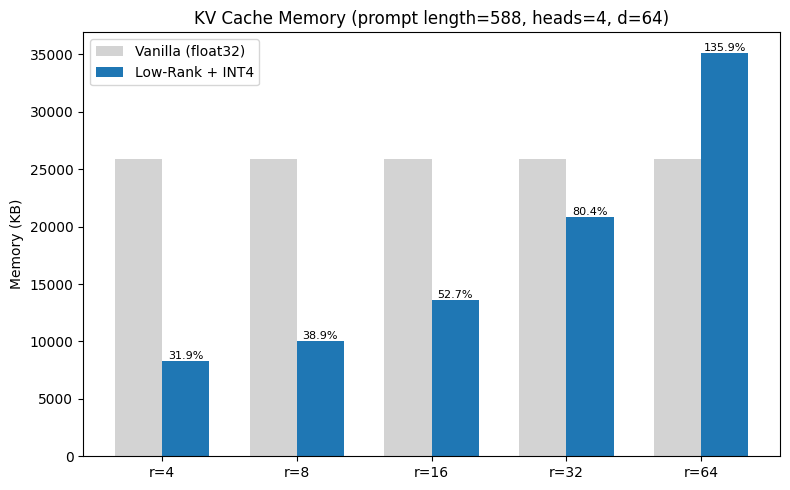

In [12]:
# ## 10. Memory Comparison: Vanilla vs Compressed KV Cache

import matplotlib.pyplot as plt
import numpy as np

def vanilla_memory(num_layers, seq_len, num_heads, head_dim, dtype_bytes=4):
    """Memory in bytes for uncompressed K+V cache (float32)."""
    # 2 matrices (K,V) per layer, each of size (seq_len, head_dim) per head
    elements = num_layers * 2 * seq_len * num_heads * head_dim
    return elements * dtype_bytes

def compressed_memory(compressed_layers):
    """Memory in bytes for low‑rank + INT4 residual representation."""
    total = 0
    for layer in compressed_layers:
        for head in layer['heads']:
            # Low‑rank factors (float32)
            total += head['L_k'].numel() * 4
            total += head['R_k'].numel() * 4
            total += head['L_v'].numel() * 4
            total += head['R_v'].numel() * 4
            # Quantised residual (int8)
            total += head['Qk'].numel() * 1
            total += head['Qv'].numel() * 1
            # Two scales (float32)
            total += 2 * 4
    return total

# Calculate vanilla memory (same for all ranks)
num_layers = len(past_key_values)
first_layer_kv = get_layer_kv(past_key_values, 0)   # (key, value)
seq_len = first_layer_kv[0].size(2)
num_heads = first_layer_kv[0].size(1)
head_dim = first_layer_kv[0].size(3)

van_mem = vanilla_memory(num_layers, seq_len, num_heads, head_dim)

# Compute compressed memory for each rank
ranks = [4, 8, 16, 32, 64]
mem_compressed = []
for r in ranks:
    comp = compress_kv_cache(past_key_values, r)   # reuse the compression function
    mem = compressed_memory(comp)
    mem_compressed.append(mem)
    ratio = mem / van_mem * 100
    print(f"Rank {r:2d}: {mem/1024:8.2f} KB  ({ratio:5.1f}% of original)")

# Plot grouped bar chart
x = np.arange(len(ranks))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_van = ax.bar(x - width/2, [van_mem/1024]*len(ranks), width,
                   label='Vanilla (float32)', color='lightgray')
bars_comp = ax.bar(x + width/2, [m/1024 for m in mem_compressed], width,
                    label='Low-Rank + INT4', color='tab:blue')
ax.set_xticks(x)
ax.set_xticklabels([f'r={r}' for r in ranks])
ax.set_ylabel('Memory (KB)')
ax.set_title(f'KV Cache Memory (prompt length={seq_len}, heads={num_heads}, d={head_dim})')
ax.legend()
# Add percentage labels on compressed bars
for bar, mem_bytes in zip(bars_comp, mem_compressed):
    pct = (mem_bytes / van_mem) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 9. Memory Saving Note

The prompt KV cache (size = prompt_len × num_heads × head_dim × 2 × num_layers floats) is replaced by:
  - Low‑rank factors: 2 × seq_len × r + 2 × r × d per head
  - INT4 quantized residual: seq_len × d int8 (≈ 0.25 of float32) per head
 
For long prompts this yields significant compression. The generation loop reconstructs the prompt cache on‑the‑fly,
so peak memory during forward passes is still high, but the *persistent* cache memory is compressed.